In [6]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
random.seed()

In [7]:
# Set vehicle limitations. They all have same capacity of 20k kg and 10 m3
truckKg = 20000
truckVol = 20
truckSpd = 0.6

In [10]:
# loading data

customersDf = pd.read_excel("2_detail_table_customers.xls")
depotsDf = pd.read_excel("4_detail_table_depots.xls")
trucksDf = pd.read_excel("3_detail_table_vehicles.xls")
routes = customersDf["ROUTE_ID"].unique()

In [11]:
routes

array([2946091, 2922001, 2939484, 2958047, 2970877, 2990001, 3005971,
       2604001, 3016355, 3027038, 3044702])

In [12]:
def getData(route, customersDf, depotsDf, trucksDf):
  '''Returns Number of Trucks, List of Customers, Cost, Demand For all Customers'''
  C_df = customersDf[customersDf['ROUTE_ID'] == route].set_index("CUSTOMER_NUMBER",drop=False).copy()
  D_df = depotsDf[depotsDf['ROUTE_ID'] == route].reset_index()

  # Grabbing the amount of trucks available for each route
  numberOfTrucks = trucksDf[trucksDf['ROUTE_ID'] == route]['VEHICLE_NUMBER'].max()

  # truckCapacityKg = 20000
  # truckCapacityVolume = 10

  # Getting id for each customer and then adding the starting node (depot). this will be used to calculate distance
  customersId = list(C_df['CUSTOMER_NUMBER'].unique())
  V = [0]+ customersId

  # Those represent the edges
  edges = [(i,j) for i in V for j in V if i != j]

  # This function gives back a dictionary that represents an edge from i to j, keys of the dictionary, and its value is the cost (time taken to travel from i to j)
  cost = getCostDict(C_df, D_df, edges)
  # This represents the demand of each customer i = (weight, volume)
  demandForCustomer = {i : (C_df.loc[i,"TOTAL_WEIGHT_KG"],C_df.loc[i,"TOTAL_VOLUME_M3"]) for i in C_df.index.to_list()}
  return (numberOfTrucks,customersId, cost, demandForCustomer)

In [13]:
def getCostDict(customers,depot, edges):
  '''This function returns a cost dict '''
  cost = {}
  depot_lat, depot_lon = depot.loc[0,"DEPOT_LATITUDE"], depot.loc[0,"DEPOT_LONGITUDE"]
  for (loc1, loc2) in edges:
    # Depot
    if loc1 == 0:
      cost[(loc1,loc2)] = round(np.hypot(depot_lat - customers.loc[loc2,"CUSTOMER_LATITUDE"],
                                   depot_lon - customers.loc[loc2,"CUSTOMER_LONGITUDE"])/truckSpd,4)
    elif loc2 == 0:
      cost[(loc1,loc2)] = round(np.hypot(depot_lat - customers.loc[loc1,"CUSTOMER_LATITUDE"],
                                   depot_lon - customers.loc[loc1,"CUSTOMER_LONGITUDE"])/truckSpd,4)
    else:
      cost[(loc1,loc2)] = round(np.hypot(customers.loc[loc1,"CUSTOMER_LATITUDE"] - customers.loc[loc2,"CUSTOMER_LATITUDE"],
                                   customers.loc[loc1,"CUSTOMER_LONGITUDE"] - customers.loc[loc2,"CUSTOMER_LONGITUDE"])/truckSpd,4)
  return cost

In [14]:
customersDf[customersDf['ROUTE_ID'] == 2946091]

,ROUTE_ID,CUSTOMER_NUMBER,CUSTOMER_CODE,CUSTOMER_LATITUDE,CUSTOMER_LONGITUDE,CUSTOMER_TIME_WINDOW_FROM_MIN,CUSTOMER_TIME_WINDOW_TO_MIN,NUMBER_OF_ARTICLES,TOTAL_WEIGHT_KG,TOTAL_VOLUME_M3,CUSTOMER_DELIVERY_SERVICE_TIME_MIN,
0,2946091,1,138087,43.413050,17.875880,480,900,42.0,64.318,0.320,19.94,
1,2946091,2,138157,43.135963,17.776839,480,900,14.0,17.553,0.046,11.36,
2,2946091,3,26,43.469078,17.337022,481,961,4.0,6.378,0.041,8.73,
3,2946091,4,478,43.707160,17.222900,481,961,5.0,16.375,0.046,9.10,
4,2946091,5,921127,43.082228,17.960037,480,840,16.0,18.939,0.074,11.99,
...,...,...,...,...,...,...,...,...,...,...,...,...
102,2946091,103,1676,43.109400,17.703620,481,961,3.0,0.598,0.002,8.26,
103,2946091,104,1805,43.381760,17.591550,481,961,8.0,172.647,0.523,13.32,
104,2946091,105,923762,43.715555,17.230788,481,961,4.0,25.716,0.149,9.36,
105,2946091,106,140023,43.469840,17.322420,481,961,7.0,87.056,0.111,10.54,


## Genetic Algorithm Utils


In [15]:
def _canAddCustomerToTruck(truck,truckCapacityKg,truckCapacityVol,singleDemand,allCustomersDemands):
  ''' This function just checks if it's possible to add the delivery of someone into a truck'''
  total_weight = sum(allCustomersDemands[customer][0] for customer in truck if customer != 0) + singleDemand[0]
  total_volume = sum(allCustomersDemands[customer][1] for customer in truck if customer != 0)+ singleDemand[1]
  return total_weight <= truckCapacityKg and total_volume <= truckCapacityVol

In [16]:
def initializePopulation(population_size,numberOfTrucks,customers,demandForCustomer):
  '''This function just initializes and returns a starting population array while keeping the constraints in mind'''
  population = []
  random.seed()

  # Keeps increasing population
  for i in range(population_size):
    trucks = [[0] for _ in range(numberOfTrucks)]
    remainingCustomers = set(customers)

    # While there are customers remaining, try to assign them to a truck
    while remainingCustomers:
      for truck in trucks:
        # Early break to avoid unnecessary iteration
        if not remainingCustomers:
          break

        # Choose a customer at random and see if its demand fits
        customerChosen = random.choice(list(remainingCustomers))
        demand = demandForCustomer[customerChosen]

        # If it does, add it to the truck and remove it from the remainingCustomers set.
        if _canAddCustomerToTruck(truck,truckKg,truckVol,demand,demandForCustomer):
          truck.append(customerChosen)
          remainingCustomers.remove(customerChosen)
    # Add 0 at the end -> go home to depot:
    for truck in trucks:
      if len(truck) > 1: # If it has at least one customer
        truck.append(0)

    population.append(trucks)

  return population

def initializeChaosPopulation(population_size, numberOfTrucks, customers):
    '''Inicializa uma população sem se preocupar com restrições (caótica)'''
    population = []
    
    for _ in range(population_size):
        # Cria as listas vazias para os caminhões com o depósito inicial [0]
        trucks = [[0] for _ in range(numberOfTrucks)]
        
        # Embaralha a lista de clientes para garantir aleatoriedade total
        shuffled_customers = list(customers)
        random.shuffle(shuffled_customers)
        
        # Distribui os clientes entre os caminhões (mesmo que fiquem pesados)
        for i, customer in enumerate(shuffled_customers):
            # Usa o resto da divisão para distribuir circularmente entre os caminhões
            truck_index = i % numberOfTrucks
            trucks[truck_index].append(customer)
            
        # Adiciona o retorno ao depósito [0] em cada caminhão
        for truck in trucks:
            truck.append(0)
            
        population.append(trucks)
        
    return population


In [17]:
trucksNo, customers, cost, demand = getData(2946091,customersDf,depotsDf,trucksDf)

In [18]:
def calculate_route_cost(route,cost):
  ''' This function calculates total route cost in terms of time '''
  totalCost = 0
  for i in range(len(route) - 1):
    edge = (route[i], route[i+1])
    totalCost += cost[edge]
  return totalCost

In [19]:
def fitnessFunction(solution, cost):
  '''Returns total cost of a solution'''
  totalCost = 0
  for route in solution:
    totalCost += calculate_route_cost(route, cost)
  return totalCost

In [20]:
def tournamentSelection(population,tournament_size,mating_pool_size, cost,fitnessScores):
  # Calculate fitness function for every individual in the population
  # fitnessScores = []
  # for individual in population:
  #   fitnessScores.append(fitnessFunction(individual,cost))

  matingPool = []


  while len(matingPool) < mating_pool_size:
    battle = random.sample(list(zip(population,fitnessScores)), tournament_size)

    # winner will be the one with the least amount of cost. he will be selected for the mating pool
    winner = min(battle,key=lambda x: x[1])

    #This intentionally allows multiple individuals from entering the mating_pool
    matingPool.append(winner[0])

  return matingPool



Now this part is tricky because we are dealing with multiple trucks. To do so, I decided to flat out all the trucks and apply the order crossover there. After that, I 'unflat' it and apply the constraints of weight and volume

In [21]:
### Order CrossOver:
# In this approach, we select 2 points in the parent sequences to define a child.

def flatten(routes):
  return [node for route in routes for node in route[1:-1]] # Not interested in the 0


def orderCrossover(parent1,parent2):
  dad = flatten(parent1)
  mom = flatten(parent2)
  child1 = [None]*len(dad)
  child2 = [None]*len(dad)

  # This gets 2 random indices where cx1 is always the smaller and cx2 the bigger
  cx1, cx2 = sorted(random.sample(range(len(dad)), 2))

  # Child inheritence from dad and mom
  child1[cx1:cx2+1] = dad[cx1:cx2+1]
  child2[cx1:cx2+1] = mom[cx1:cx2+1]

  # Inherent from mom and dad

  position = 0
  for node in mom:
    # If position is cx1, that means it has already gotten the node from the father
    if position == cx1:
      position = cx2 + 1

  # Just double checking to make sure it stays correct (only 1 visit per node)
    if node not in child1:
      child1[position] = node
      position += 1

  position = 0
  for node in dad:
    # same thing to the dad.
    if position == cx1:
      position = cx2 + 1
    if node not in child2:
      child2[position] = node
      position += 1

  return child1, child2

def reconstruct_routes(flat_sequence, truckCapacityKg, truckCapacityVolume, demandForCustomer, numberOfTrucks):
    '''This function is to just recover the sequence after flattening it'''
    
    # 1. Correção: Gerando as listas de rotas de forma independente
    trucks = [[0] for _ in range(numberOfTrucks)]
    
    customerRemaining = flat_sequence.copy()
    
    while customerRemaining:
        added = False
        for i in range(len(trucks)):
            if not customerRemaining:
                break
                
            customerChosen = customerRemaining[0]
            demand = demandForCustomer[customerChosen]
            
            # 2. Correção: usando as variáveis locais (truckCapacityKg) em vez de truckKg global
            if _canAddCustomerToTruck(trucks[i], truckCapacityKg, truckCapacityVolume, demand, demandForCustomer):
                # 3. Correção do erro principal: substituído 'truck' por 'trucks[i]'
                trucks[i].append(customerChosen)
                customerRemaining.pop(0)
                added = True
                
        # Prevenção contra loop infinito: se o cliente não couber em NENHUM caminhão
        # (pode acontecer durante mutações severas) quebramos o loop.
        if not added and customerRemaining:
            break
            
    # Adiciona o retorno ao depósito (0) no final de rotas não vazias
    for truck in trucks:
        if len(truck) > 1:
            truck.append(0)

    # O resto de código obsoleto (current_weight, current_route, etc) 
    # foi removido, pois a sua lógica do "while" agora cria e retorna 'trucks' direto.
    return trucks

# def treatCrossOver(parents,truckCapacityKg,truckCapacityVol,demandForCustomer, numberOfTrucks):
#   if len(parents) % 2 != 0:
#     print("Not matching crossover")
#     return -1
#   parents1 = parents[:len(parents)//2]
#   parents2 = parents[len(parents)//2:]

#   population = []
#   for (dad,mom) in zip(parents1,parents2):
#     (child1,child2) = orderCrossover(dad,mom)
#     route1 = reconstruct_routes(child1,truckCapacityKg,truckCapacityVol,demandForCustomer, numberOfTrucks)
#     route2 = reconstruct_routes(child2,truckCapacityKg,truckCapacityVol,demandForCustomer, numberOfTrucks)
#     population.append(route1)
#     population.append(route2)
          
#   return population

def treatCrossOver(parents,truckCapacityKg,truckCapacityVol,demandForCustomer, numberOfTrucks):
    if len(parents) % 2 != 0:
        print("Not matching crossover")
        return -1
    
    parents1 = parents[:len(parents)//2]
    parents2 = parents[len(parents)//2:]

    population = []
    for (dad, mom) in zip(parents1, parents2):
        # Usando o Order Crossover achatado
        (child1_flat, child2_flat) = orderCrossover(dad, mom)
        
        # Reconstruindo usando a nova função divisora simples
        route1 = reconstruct_routes_for_penalties(child1_flat, numberOfTrucks)
        route2 = reconstruct_routes_for_penalties(child2_flat, numberOfTrucks)

        # # Gera o Filho 1: Preserva uma rota do Pai, preenche com a genética da Mãe
        # route1 = routeBasedCrossover(dad, mom, truckCapacityKg, truckCapacityVol, demandForCustomer, numberOfTrucks)
        # # Gera o Filho 2: Preserva uma rota da Mãe, preenche com a genética do Pai
        # route2 = routeBasedCrossover(mom, dad, truckCapacityKg, truckCapacityVol, demandForCustomer, numberOfTrucks)
        
        population.append(route1)
        population.append(route2)
        
    return population

def routeBasedCrossover(parent1, parent2, truckCapacityKg, truckCapacityVolume, demandForCustomer, numberOfTrucks):
    """
    Implementação do Route-Based Crossover (RBX).
    Gera 1 filho a partir de 2 pais, preservando rotas otimizadas.
    """
    # 1. Limpar os depósitos (0) para facilitar a manipulação dos genes
    p1_clean = [[node for node in truck if node != 0] for truck in parent1]
    p2_clean = [[node for node in truck if node != 0] for truck in parent2]
    
    # Filtrar apenas os camiões que realmente têm clientes (ignorar camiões vazios)
    p1_valid_routes = [route for route in p1_clean if len(route) > 0]
    
    # Se o Pai 1 estiver vazio por algum motivo, retorna o Pai 2 por segurança
    if not p1_valid_routes:
        return parent2
        
    # 2. HERANÇA INTACTA: Sorteia UMA rota inteira do Pai 1 para ser preservada
    preserved_route = random.choice(p1_valid_routes)
    
    # O Filho já nasce com essa rota perfeitamente otimizada (voltando a colocar os depósitos)
    child = [[0] + preserved_route + [0]]
    
    # 3. PREENCHIMENTO: Pega nos clientes da Mãe (Pai 2) mantendo a sua ordem relativa, 
    # mas EXCLUI os clientes que já estão na rota preservada do Pai 1
    mom_flat = [node for route in p2_clean for node in route]
    remaining_customers = [node for node in mom_flat if node not in preserved_route]
    
    # 4. RECONSTRUÇÃO: Reconstrói os camiões restantes apenas para os clientes que faltam
    trucks_needed = numberOfTrucks - 1
    
    if trucks_needed > 0 and remaining_customers:
        other_trucks = [[0] for _ in range(trucks_needed)]
        customerRemaining = remaining_customers.copy()
        
        while customerRemaining:
            added = False
            for i in range(len(other_trucks)):
                if not customerRemaining: 
                    break
                    
                customerChosen = customerRemaining[0]
                demand = demandForCustomer[customerChosen]
                
                # Usa a tua função de validação de peso/volume já existente
                if _canAddCustomerToTruck(other_trucks[i], truckCapacityKg, truckCapacityVolume, demand, demandForCustomer):
                    other_trucks[i].append(customerChosen)
                    customerRemaining.pop(0)
                    added = True
                    
            # Prevenção contra loops infinitos caso um cliente não caiba em mais nenhum lado
            if not added and customerRemaining:
                break
        
        # Finaliza as rotas restantes adicionando o retorno ao depósito (0)
        for t in other_trucks:
            if len(t) > 1:
                t.append(0)
                child.append(t)
                
    # 5. Se o filho tiver menos camiões que o total, preenchemos com rotas vazias
    while len(child) < numberOfTrucks:
        child.append([0, 0])
        
    return child


def reconstruct_routes_for_penalties(flat_sequence, numberOfTrucks):
    # Divide a lista contínua de clientes em fatias iguais para os camiões
    # Ex: 10 clientes para 2 camiões = 5 para cada
    chunk_size = len(flat_sequence) // numberOfTrucks + 1
    
    trucks = []
    for i in range(numberOfTrucks):
        # Pega a fatia
        start = i * chunk_size
        end = start + chunk_size
        fatia = flat_sequence[start:end]
        
        # Se a fatia tiver clientes, coloca os depósitos (0) nas pontas
        if len(fatia) > 0:
            trucks.append([0] + fatia + [0])
        else:
            trucks.append([0, 0]) # Camião vazio
            
    return trucks


In [22]:
# def mutation(solution, demandForCustomer, truckCapacityKg, truckCapacityVolume):


#     # Randomly select one truck
#     truck_index = random.randint(0, len(solution) - 1)
#     route = solution[truck_index]

#     # Ensure there are enough customers for a swap
#     if len(route) > 4:  # More than just depot (start/end) and one customer
#         # Randomly select two customers to swap
#         customer_index1, customer_index2 = random.sample(range(1, len(route) - 1), 2)

#         # Perform the swap
#         route[customer_index1], route[customer_index2] = route[customer_index2], route[customer_index1]

#         # Check capacity constraints and revert if necessary
#         total_weight, total_volume = 0, 0
#         for node in route[1:-1]:
#             node_weight, node_volume = demandForCustomer[node]
#             total_weight += node_weight
#             total_volume += node_volume

#         # Revert the swap if the mutation results in an infeasible route
#         if total_weight > truckCapacityKg or total_volume > truckCapacityVolume:
#             route[customer_index1], route[customer_index2] = route[customer_index2], route[customer_index1]
#     return solution

def mutation(population, mutationRate):
    for individual in population:
        if random.random() < mutationRate:
            # Escolhe dois camiões aleatórios do indivíduo (podem ser o mesmo camião)
            truck1_idx = random.randint(0, len(individual) - 1)
            truck2_idx = random.randint(0, len(individual) - 1)
            
            truck1 = individual[truck1_idx]
            truck2 = individual[truck2_idx]
            
            # Só faz a mutação se ambos os camiões tiverem clientes (tamanho > 2 por causa dos depósitos [0, ..., 0])
            if len(truck1) > 2 and len(truck2) > 2:
                # Escolhe clientes aleatórios (ignorando os depósitos nas posições 0 e -1)
                cust1_idx = random.randint(1, len(truck1) - 2)
                cust2_idx = random.randint(1, len(truck2) - 2)
                
                # Troca os clientes livremente (SEM verificar peso!)
                truck1[cust1_idx], truck2[cust2_idx] = truck2[cust2_idx], truck1[cust1_idx]
                
    return population


## Main Algorithm

In [32]:
def apply_2opt(route, costDict):
    best_route = route.copy()
    improved = True
    
    while improved:
        improved = False
        # Testamos todos os pares possíveis (i, j)
        # Ignoramos o primeiro e o último (depósitos)
        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route) - 1):
                # Se inverter esse segmento diminuir a distância...
                
                # Custo atual dos links que serão quebrados
                old_cost = costDict[(best_route[i-1], best_route[i])] + \
                           costDict[(best_route[j], best_route[j+1])]
                
                # Novo custo dos links que serão criados após a inversão
                new_cost = costDict[(best_route[i-1], best_route[j])] + \
                           costDict[(best_route[i], best_route[j+1])]
                
                if new_cost < old_cost:
                    # Inverte o segmento entre i e j
                    best_route[i:j+1] = best_route[i:j+1][::-1]
                    improved = True
        # Para não ficar em loop infinito, podemos sair após a primeira melhoria
        if improved: break 
        
    return best_route

def local_search_mutation(population, costDict, mutationRate):
    new_population = []
    
    for individual in population:
        # Criamos uma cópia para não alterar o original sem querer
        new_individual = [route.copy() for route in individual]
        
        # Se o sorteio cair na taxa de mutação, aplicamos o 2-opt
        if random.random() < mutationRate:
            # Aplicamos em todos os camiões desse indivíduo
            for k in range(len(new_individual)):
                if len(new_individual[k]) > 4: # Só faz sentido se tiver pelo menos 3 clientes + depósitos
                    new_individual[k] = apply_2opt(new_individual[k], costDict)
        
        new_population.append(new_individual)
        
    return new_population

def inter_truck_local_search(population, costDict, mutationRate):
    """
    Tenta mover um cliente de um camião para outro (Relocate) para poupar distância.
    """
    new_population = []
    
    for individual in population:
        # Cópia de segurança para não alterar o original diretamente
        new_ind = [route.copy() for route in individual]
        
        if random.random() < mutationRate:
            # Escolhe um camião de origem que tenha clientes (tamanho > 2 devido aos depósitos [0, ..., 0])
            valid_sources = [i for i in range(len(new_ind)) if len(new_ind[i]) > 2]
            
            if len(valid_sources) >= 1:
                t_from = random.choice(valid_sources)
                
                # Escolhe um cliente aleatório para remover (ignora os depósitos 0 no início e fim)
                cust_idx = random.randint(1, len(new_ind[t_from]) - 2)
                customer = new_ind[t_from][cust_idx]
                
                # Escolhe um camião de destino diferente
                valid_dests = [i for i in range(len(new_ind)) if i != t_from]
                if valid_dests:
                    t_to = random.choice(valid_dests)
                    
                    # Remove do camião de origem
                    new_ind[t_from].pop(cust_idx)
                    
                    # Tenta inserir na melhor posição do camião de destino
                    best_insert_idx = 1
                    best_cost_diff = float('inf')
                    
                    # Testa todas as posições de inserção no camião de destino
                    for insert_idx in range(1, len(new_ind[t_to])):
                        # Calcula a diferença de custo ao inserir aqui
                        prev_node = new_ind[t_to][insert_idx - 1]
                        next_node = new_ind[t_to][insert_idx]
                        
                        # Custo adicionado pela inserção
                        cost_added = costDict[(prev_node, customer)] + costDict[(customer, next_node)]
                        # Custo removido (a ligação antiga que foi quebrada)
                        cost_removed = costDict[(prev_node, next_node)]
                        
                        diff = cost_added - cost_removed
                        if diff < best_cost_diff:
                            best_cost_diff = diff
                            best_insert_idx = insert_idx
                            
                    # Insere o cliente na melhor posição encontrada
                    new_ind[t_to].insert(best_insert_idx, customer)
                    
        new_population.append(new_ind)
        
    return new_population

def fitnessFunctionWithPenalties(solution, costDict, demandForCustomer, truckCapacityKg, truckCapacityVolume, penaltyFactor):
    totalCost = 0
    penalty = 0
    
    for route in solution:
        # Custo normal de tempo/distância
        totalCost += calculate_route_cost(route, costDict)
        
        # Avaliar limites de peso e volume
        total_weight, total_volume = 0, 0
        for node in route:
            if node != 0: # ignorar os depósitos
                node_weight, node_volume = demandForCustomer[node]
                total_weight += node_weight
                total_volume += node_volume
                
        # Calcular excesso
        excess_weight = max(0, total_weight - truckCapacityKg)
        excess_volume = max(0, total_volume - truckCapacityVolume)
        
        # Se ultrapassar as restrições, aplica-se o fator de penalização gerado na geração atual
        if excess_weight > 0 or excess_volume > 0:
            penalty += (excess_weight + excess_volume) * penaltyFactor
            
    return totalCost + penalty

def genetic_algorithm(populationSize, numberOfTrucks, truckCapacityKg, truckCapacityVol, customersId, cost, demandForCustomer, maxGenNumber=340, baseMutationRate=0.05):
    
    # Inicialização Híbrida (Metade legal, metade caótica)
    pop_legal = initializePopulation(int(populationSize*0.5), numberOfTrucks, customersId, demandForCustomer)
    pop_caotica = initializeChaosPopulation(int(populationSize*0.5), numberOfTrucks, customersId)
    population = pop_legal + pop_caotica
    
    # Se a divisão foi ímpar e faltou 1, adiciona um aleatório:
    while len(population) < populationSize:
        population.append(initializeChaosPopulation(1, numberOfTrucks, customersId)[0])

    print("Population generated")
    
    generations = 0
    best_solution = None
    best_fitness = float('inf')
    history = []
    
    # Variáveis para a Mutação Adaptativa (Eletrochoque)
    estagnacao = 0
    current_mutation_rate = baseMutationRate
    
    while generations < maxGenNumber:
        
        # Penalidade Dinâmica: Começa em 100 e vai até 10000 no final da evolução
        progress = generations / maxGenNumber
        current_penalty = 100 + (progress * 9900)
        
        # Calcula o fitness usando a penalidade dinâmica
        fitnesses = []
        for sol in population:
            score = fitnessFunctionWithPenalties(sol, cost, demandForCustomer, truckCapacityKg, truckCapacityVol, current_penalty)
            fitnesses.append(score)

        # Atualiza o melhor da geração
        generation_best_fitness = float('inf')
        for i, fitness in enumerate(fitnesses):
            if fitness < best_fitness:
                best_fitness = fitness
                best_solution = population[i].copy()
            
            # Para controlar a estagnação local
            if fitness < generation_best_fitness:
                generation_best_fitness = fitness

        # Mutação Adaptativa: Se o melhor fitness não mudou, aumenta a estagnação
        if history and generation_best_fitness >= history[-1]:
            estagnacao += 1
        else:
            estagnacao = 0
            current_mutation_rate = baseMutationRate # Volta ao normal se melhorou
            
        # Aplica o "Eletrochoque" se estiver preso há 15 gerações
        if estagnacao > 15:
            current_mutation_rate = 0.30 # Aumenta a mutação para 30% temporariamente
            
        # Torneio e Crossover
        winners = tournamentSelection(population, 2, len(population), cost, fitnesses)
        population = treatCrossOver(winners, truckCapacityKg, truckCapacityVol, demandForCustomer, numberOfTrucks)

        # Mutações e Buscas Locais (usando a taxa adaptativa)
        # Trocas aleatórias padrão
        population = mutation(population, current_mutation_rate)
        
        # Busca Local entre Camiões
        population = inter_truck_local_search(population, cost, current_mutation_rate)
        
        # Busca Local dentro do Camião (o 2-opt)
        population = local_search_mutation(population, cost, current_mutation_rate)

        # ELITISMO: Salva o melhor indivíduo absoluto de ser destruído
        population[0] = best_solution.copy()

        generations += 1
        history.append(best_fitness)
        
        if generations % 50 == 0 or generations == maxGenNumber:
            print(f"Generation {generations}: Best Fitness = {best_fitness:.2f} | Penalty Factor = {current_penalty:.0f}")

    print(f"\nBest Solution Found: {best_solution}")
    print(f"Final Fitness: {best_fitness:.2f}")
    
    return best_solution, best_fitness, history



In [29]:
routes

array([2946091, 2922001, 2939484, 2958047, 2970877, 2990001, 3005971,
       2604001, 3016355, 3027038, 3044702])

In [33]:
(numberOfTrucks,customers,cost,demandForAll) = getData(2946091,customersDf,depotsDf,trucksDf)
best_solution,best_fitness,history = genetic_algorithm(100,numberOfTrucks,truckKg,truckVol,customers,cost,demandForAll,maxGenNumber=540)


Population generated
Generation 50: Best Fitness = 20.66 | Penalty Factor = 998
Generation 100: Best Fitness = 17.66 | Penalty Factor = 1915
Generation 150: Best Fitness = 16.73 | Penalty Factor = 2832
Generation 200: Best Fitness = 16.27 | Penalty Factor = 3748
Generation 250: Best Fitness = 16.27 | Penalty Factor = 4665
Generation 300: Best Fitness = 16.27 | Penalty Factor = 5582
Generation 350: Best Fitness = 16.27 | Penalty Factor = 6498
Generation 400: Best Fitness = 16.27 | Penalty Factor = 7415
Generation 450: Best Fitness = 16.27 | Penalty Factor = 8332
Generation 500: Best Fitness = 16.27 | Penalty Factor = 9248
Generation 540: Best Fitness = 16.27 | Penalty Factor = 9982

Best Solution Found: [[0, np.int64(104), np.int64(75), np.int64(76), np.int64(22), np.int64(13), np.int64(107), np.int64(32), np.int64(51), np.int64(34), np.int64(31), np.int64(105), np.int64(100), np.int64(64), np.int64(8), 0], [0, np.int64(106), np.int64(50), np.int64(15), np.int64(35), np.int64(78), np.in

In [ ]:
customersDf.head()

,ROUTE_ID,CUSTOMER_NUMBER,CUSTOMER_CODE,CUSTOMER_LATITUDE,CUSTOMER_LONGITUDE,CUSTOMER_TIME_WINDOW_FROM_MIN,CUSTOMER_TIME_WINDOW_TO_MIN,NUMBER_OF_ARTICLES,TOTAL_WEIGHT_KG,TOTAL_VOLUME_M3,CUSTOMER_DELIVERY_SERVICE_TIME_MIN,
0,2946091,1,138087,43.413050,17.875880,480,900,42.0,64.318,0.320,19.94,
1,2946091,2,138157,43.135963,17.776839,480,900,14.0,17.553,0.046,11.36,
2,2946091,3,26,43.469078,17.337022,481,961,4.0,6.378,0.041,8.73,
3,2946091,4,478,43.707160,17.222900,481,961,5.0,16.375,0.046,9.10,
4,2946091,5,921127,43.082228,17.960037,480,840,16.0,18.939,0.074,11.99,


In [ ]:
def plotprettylineplot(history, route_id):
  x = range(1,len(history)+1)
  y = history
  sns.set_style("darkgrid")


  sns.lineplot(x=x,y=y)


  plt.title(f'Fitness Over Generations\n Route-id {route_id}', fontsize=16, fontweight='bold')
  plt.xlabel('Generation', fontsize=14)
  plt.ylabel('Fitness', fontsize=14)


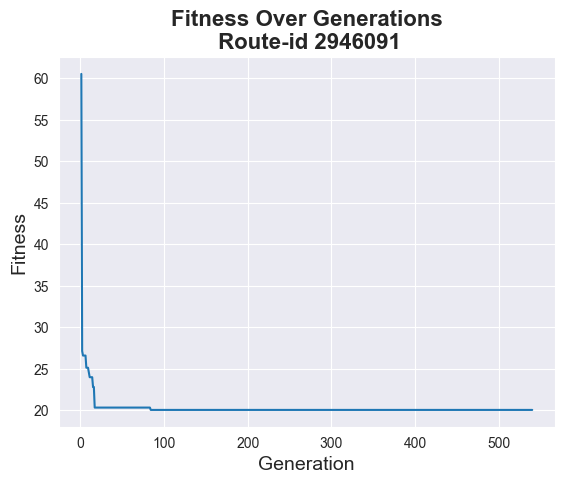

In [ ]:
plotprettylineplot(history,2946091)

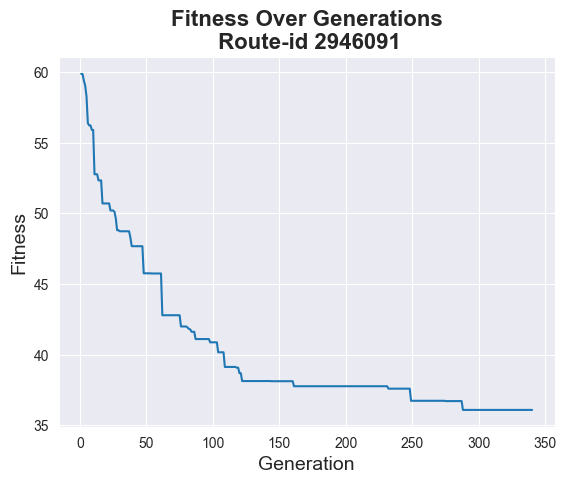

In [ ]:
plotprettylineplot(history,2946091)

In [ ]:
(numberOfTrucks,customers,cost,demandForAll) = getData(2922001,customersDf,depotsDf,trucksDf)
best_solution,best_fitness,history = genetic_algorithm(100,numberOfTrucks,truckKg,truckVol,customers,cost,demandForAll,maxGenNumber=340,mutationRate=0.12)

Population generated
Generation 321: Best Fitness = 35.2611
Generation 322: Best Fitness = 35.2611
Generation 323: Best Fitness = 35.2611
Generation 324: Best Fitness = 35.256899999999995
Generation 325: Best Fitness = 35.256299999999996
Generation 326: Best Fitness = 35.256299999999996
Generation 327: Best Fitness = 35.256299999999996
Generation 328: Best Fitness = 35.256299999999996
Generation 329: Best Fitness = 35.256299999999996
Generation 330: Best Fitness = 35.256299999999996
Generation 331: Best Fitness = 35.256299999999996
Generation 332: Best Fitness = 35.256299999999996
Generation 333: Best Fitness = 35.23529999999999
Generation 334: Best Fitness = 35.23529999999999
Generation 335: Best Fitness = 35.23529999999999
Generation 336: Best Fitness = 35.23529999999999
Generation 337: Best Fitness = 35.227999999999994
Generation 338: Best Fitness = 35.227999999999994
Generation 339: Best Fitness = 35.224299999999985
Generation 340: Best Fitness = 35.216499999999996

Best Solution F

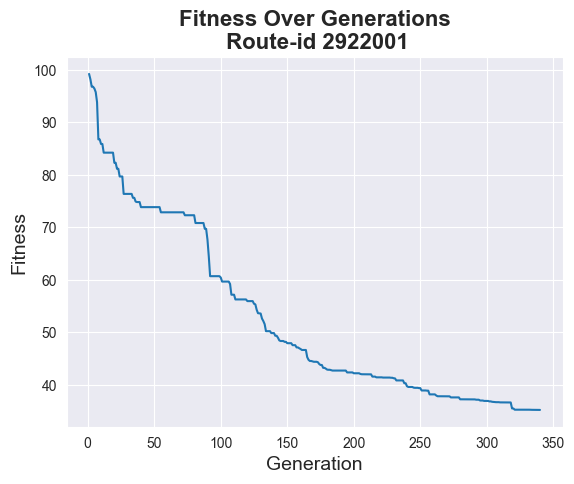

In [ ]:
plotprettylineplot(history,2922001)

In [ ]:
(numberOfTrucks,customers,cost,demandForAll) = getData(2939484,customersDf,depotsDf,trucksDf)
best_solution,best_fitness,history = genetic_algorithm(100,numberOfTrucks,truckKg,truckVol,customers,cost,demandForAll,maxGenNumber=340,mutationRate=0.12)

Population generated
Generation 321: Best Fitness = 18.940099999999997
Generation 322: Best Fitness = 18.940099999999997
Generation 323: Best Fitness = 18.924
Generation 324: Best Fitness = 18.924
Generation 325: Best Fitness = 18.924
Generation 326: Best Fitness = 18.924
Generation 327: Best Fitness = 18.924
Generation 328: Best Fitness = 18.924
Generation 329: Best Fitness = 18.924
Generation 330: Best Fitness = 18.924
Generation 331: Best Fitness = 18.924
Generation 332: Best Fitness = 18.924
Generation 333: Best Fitness = 18.901899999999998
Generation 334: Best Fitness = 18.901899999999998
Generation 335: Best Fitness = 18.901899999999998
Generation 336: Best Fitness = 18.8992
Generation 337: Best Fitness = 18.8992
Generation 338: Best Fitness = 18.899199999999997
Generation 339: Best Fitness = 18.899199999999997
Generation 340: Best Fitness = 18.899199999999997

Best Solution Found: [[0, np.int64(53), np.int64(23), np.int64(21), np.int64(39), np.int64(7), np.int64(16), np.int64(68

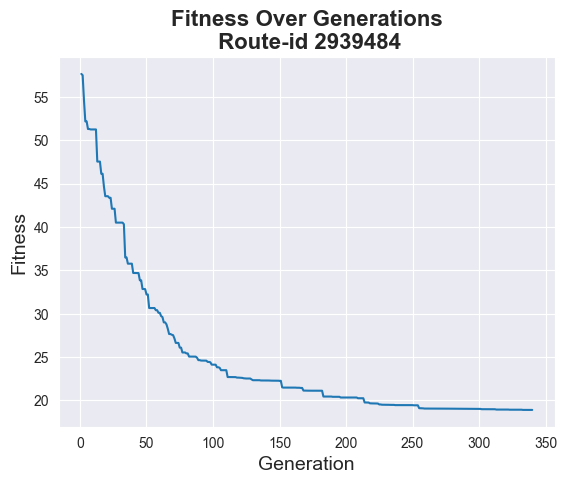

In [ ]:
plotprettylineplot(history,2939484)

Population generated
Generation 321: Best Fitness = 24.839800000000015
Generation 322: Best Fitness = 24.775700000000008
Generation 323: Best Fitness = 24.775700000000008
Generation 324: Best Fitness = 24.77220000000001
Generation 325: Best Fitness = 24.77220000000001
Generation 326: Best Fitness = 24.77220000000001
Generation 327: Best Fitness = 24.76110000000001
Generation 328: Best Fitness = 24.76110000000001
Generation 329: Best Fitness = 24.76110000000001
Generation 330: Best Fitness = 24.76110000000001
Generation 331: Best Fitness = 24.76110000000001
Generation 332: Best Fitness = 24.76110000000001
Generation 333: Best Fitness = 24.76110000000001
Generation 334: Best Fitness = 24.75760000000001
Generation 335: Best Fitness = 24.75760000000001
Generation 336: Best Fitness = 24.75760000000001
Generation 337: Best Fitness = 24.75250000000001
Generation 338: Best Fitness = 24.75250000000001
Generation 339: Best Fitness = 24.75250000000001
Generation 340: Best Fitness = 24.75250000000

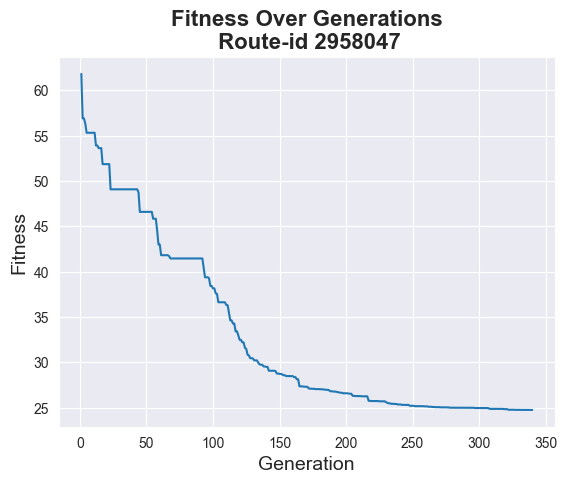

In [ ]:
id = 2958047
(numberOfTrucks,customers,cost,demandForAll) = getData(id,customersDf,depotsDf,trucksDf)
best_solution,best_fitness,history = genetic_algorithm(100,numberOfTrucks,truckKg,truckVol,customers,cost,demandForAll,maxGenNumber=340,mutationRate=0.12)
plotprettylineplot(history,id)

In [ ]:
def show(id):
  (numberOfTrucks,customers,cost,demandForAll) = getData(id,customersDf,depotsDf,trucksDf)
  best_solution,best_fitness,history = genetic_algorithm(100,numberOfTrucks,truckKg,truckVol,customers,cost,demandForAll,maxGenNumber=340,mutationRate=0.12)
  plotprettylineplot(history,id)

Population generated
Generation 321: Best Fitness = 31.934399999999997
Generation 322: Best Fitness = 31.730799999999988
Generation 323: Best Fitness = 31.730799999999988
Generation 324: Best Fitness = 31.730799999999988
Generation 325: Best Fitness = 31.730799999999988
Generation 326: Best Fitness = 31.730799999999988
Generation 327: Best Fitness = 31.730799999999988
Generation 328: Best Fitness = 31.55380000000001
Generation 329: Best Fitness = 31.318800000000007
Generation 330: Best Fitness = 31.318800000000007
Generation 331: Best Fitness = 31.318800000000007
Generation 332: Best Fitness = 31.2733
Generation 333: Best Fitness = 31.2733
Generation 334: Best Fitness = 31.2733
Generation 335: Best Fitness = 31.272
Generation 336: Best Fitness = 31.272
Generation 337: Best Fitness = 31.272
Generation 338: Best Fitness = 31.272
Generation 339: Best Fitness = 31.272
Generation 340: Best Fitness = 31.272

Best Solution Found: [[0, np.int64(42), np.int64(34), np.int64(35), np.int64(60), np

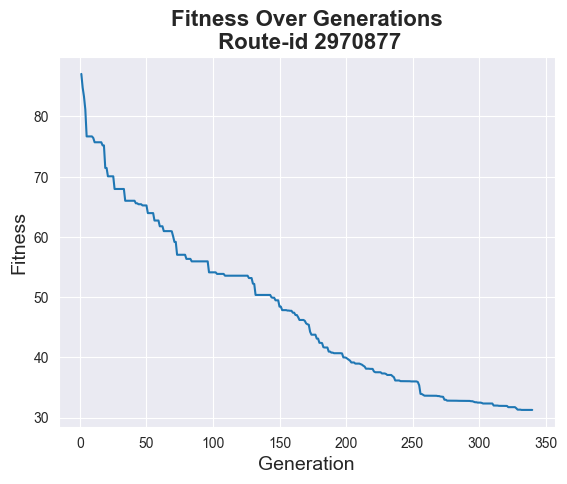

In [ ]:
show(2970877)

In [ ]:
routes

array([2946091, 2922001, 2939484, 2958047, 2970877, 2990001, 3005971,
       2604001, 3016355, 3027038, 3044702])

Population generated
Generation 321: Best Fitness = 24.397399999999994
Generation 322: Best Fitness = 24.397399999999994
Generation 323: Best Fitness = 24.397399999999994
Generation 324: Best Fitness = 24.397399999999994
Generation 325: Best Fitness = 24.397399999999994
Generation 326: Best Fitness = 24.397399999999994
Generation 327: Best Fitness = 24.394999999999992
Generation 328: Best Fitness = 24.394999999999992
Generation 329: Best Fitness = 24.394999999999992
Generation 330: Best Fitness = 24.394999999999992
Generation 331: Best Fitness = 24.394999999999992
Generation 332: Best Fitness = 24.394999999999992
Generation 333: Best Fitness = 24.183399999999992
Generation 334: Best Fitness = 24.183399999999992
Generation 335: Best Fitness = 24.183099999999996
Generation 336: Best Fitness = 24.183099999999996
Generation 337: Best Fitness = 24.183099999999996
Generation 338: Best Fitness = 24.183099999999996
Generation 339: Best Fitness = 24.183099999999996
Generation 340: Best Fitness 

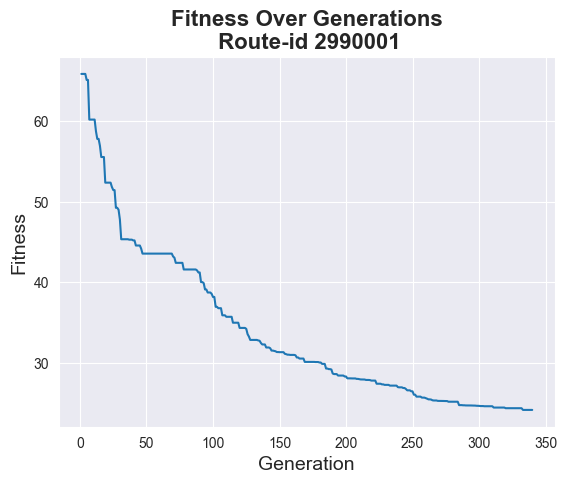

In [ ]:
show(2990001)

Population generated
Generation 321: Best Fitness = 27.2172
Generation 322: Best Fitness = 27.2172
Generation 323: Best Fitness = 27.2172
Generation 324: Best Fitness = 26.854799999999997
Generation 325: Best Fitness = 26.854799999999997
Generation 326: Best Fitness = 26.854799999999997
Generation 327: Best Fitness = 26.854799999999997
Generation 328: Best Fitness = 26.1265
Generation 329: Best Fitness = 26.1265
Generation 330: Best Fitness = 26.1265
Generation 331: Best Fitness = 26.1265
Generation 332: Best Fitness = 26.1265
Generation 333: Best Fitness = 26.1265
Generation 334: Best Fitness = 26.1265
Generation 335: Best Fitness = 26.1265
Generation 336: Best Fitness = 26.1265
Generation 337: Best Fitness = 26.1265
Generation 338: Best Fitness = 26.1265
Generation 339: Best Fitness = 26.1265
Generation 340: Best Fitness = 26.1265

Best Solution Found: [[0, np.int64(72), np.int64(19), np.int64(26), np.int64(3), np.int64(90), np.int64(69), np.int64(98), np.int64(31), np.int64(38), np.

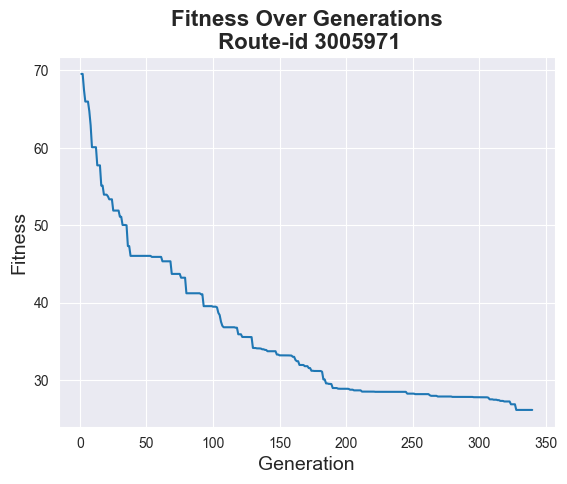

In [ ]:
show(3005971)

Population generated
Generation 321: Best Fitness = 22.93819999999999
Generation 322: Best Fitness = 22.93819999999999
Generation 323: Best Fitness = 22.93819999999999
Generation 324: Best Fitness = 22.92349999999999
Generation 325: Best Fitness = 22.90789999999999
Generation 326: Best Fitness = 22.90789999999999
Generation 327: Best Fitness = 22.899199999999993
Generation 328: Best Fitness = 22.899199999999993
Generation 329: Best Fitness = 22.890299999999993
Generation 330: Best Fitness = 22.88499999999999
Generation 331: Best Fitness = 22.88499999999999
Generation 332: Best Fitness = 22.86939999999999
Generation 333: Best Fitness = 22.855499999999996
Generation 334: Best Fitness = 22.855499999999996
Generation 335: Best Fitness = 22.846699999999995
Generation 336: Best Fitness = 22.832599999999996
Generation 337: Best Fitness = 22.816999999999997
Generation 338: Best Fitness = 22.816999999999997
Generation 339: Best Fitness = 22.816999999999997
Generation 340: Best Fitness = 22.8169

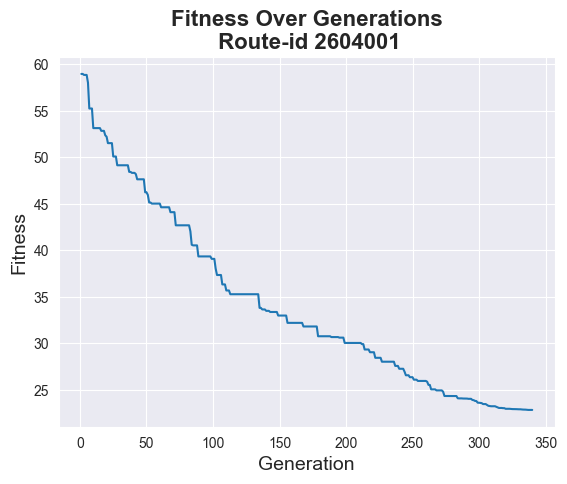

In [ ]:
show(2604001)

In [ ]:
show(3016355)

KeyboardInterrupt: 

Population generated
Generation 321: Best Fitness = 17.853
Generation 322: Best Fitness = 17.848300000000002
Generation 323: Best Fitness = 17.848300000000002
Generation 324: Best Fitness = 17.674900000000004
Generation 325: Best Fitness = 17.674900000000004
Generation 326: Best Fitness = 17.674900000000004
Generation 327: Best Fitness = 17.661500000000004
Generation 328: Best Fitness = 17.661500000000004
Generation 329: Best Fitness = 17.661500000000004
Generation 330: Best Fitness = 17.661500000000004
Generation 331: Best Fitness = 17.661500000000004
Generation 332: Best Fitness = 17.661500000000004
Generation 333: Best Fitness = 17.6555
Generation 334: Best Fitness = 17.6555
Generation 335: Best Fitness = 17.6555
Generation 336: Best Fitness = 17.6555
Generation 337: Best Fitness = 17.6555
Generation 338: Best Fitness = 17.587300000000006
Generation 339: Best Fitness = 17.587300000000006
Generation 340: Best Fitness = 17.587300000000006

Best Solution Found: [[0, np.int64(62), np.in

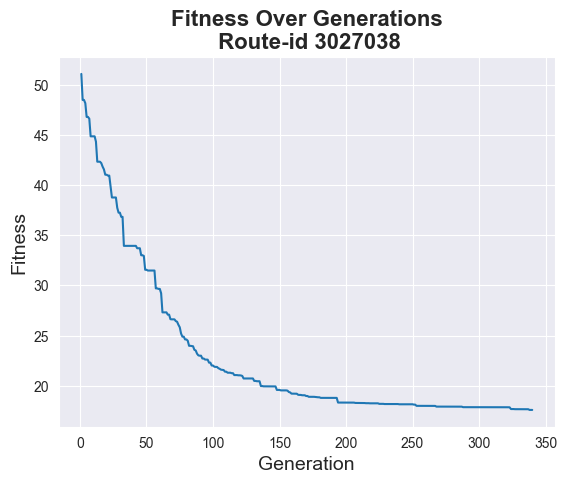

In [ ]:
show(3027038)

population generated
Generation 321: Best Fitness = 15.213300000000002
Generation 322: Best Fitness = 15.213300000000002
Generation 323: Best Fitness = 15.213300000000002
Generation 324: Best Fitness = 15.213300000000002
Generation 325: Best Fitness = 15.213300000000002
Generation 326: Best Fitness = 15.213300000000002
Generation 327: Best Fitness = 15.213300000000002
Generation 328: Best Fitness = 15.213300000000002
Generation 329: Best Fitness = 15.203400000000002
Generation 330: Best Fitness = 15.186499999999999
Generation 331: Best Fitness = 15.186499999999999
Generation 332: Best Fitness = 15.186499999999999
Generation 333: Best Fitness = 15.186499999999999
Generation 334: Best Fitness = 15.186499999999999
Generation 335: Best Fitness = 15.186499999999999
Generation 336: Best Fitness = 15.186499999999999
Generation 337: Best Fitness = 15.186499999999999
Generation 338: Best Fitness = 15.186499999999999
Generation 339: Best Fitness = 15.186499999999999
Generation 340: Best Fitness 

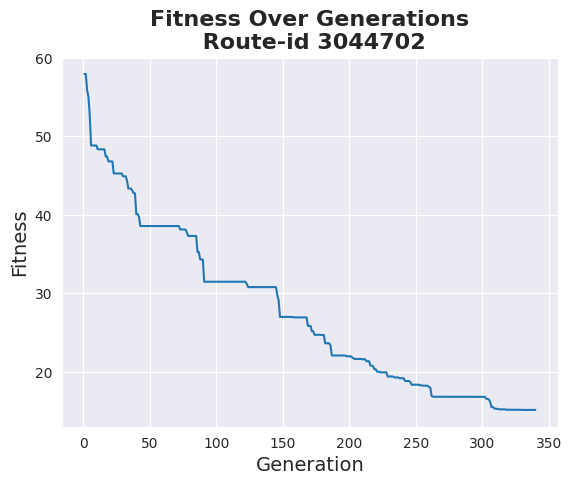

In [ ]:
show(3044702)